In [13]:
from lib_analysis_lolss import *
from matplotlib.patches import Rectangle
from astropy_healpix import HEALPix
hp = HEALPix(nside=16)

%matplotlib inline

Ratios: [0.00000000e+00 4.49236298e-04 1.96270854e-03 1.06553010e-03
 5.80046404e-04 6.17283951e-03 2.11267606e-02 4.13895048e-02
 1.07142857e-01 2.22831050e-01 3.75745527e-01 5.58670820e-01
 7.26757370e-01 8.13888889e-01 8.43631778e-01 9.06743185e-01
 9.30578512e-01 9.20338983e-01 9.53535354e-01]
Fraction 0.3789312977099237 above 2.0 -- 11169 of 29475 -- 0.005824693711073587 error
Fraction 0.41276469936065635 above 2.306372948786599 -- 11169 of 27059 -- 0.006079167765402461 error
Fraction 0.4497241573712399 above 2.659678089447296 -- 11168 of 24833 -- 0.0063457857590126085 error
Fraction 0.4897565255538495 above 3.0671047989908335 -- 11164 of 22795 -- 0.006623388073838158 error
Fraction 0.5336074194473659 above 3.5369437697430093 -- 11162 of 20918 -- 0.006914167886580469 error
Fraction 0.581483797019902 above 4.0787557159572865 -- 11161 of 19194 -- 0.007218006266473656 error
Fraction 0.6345168999658587 above 4.7035659239963 -- 11151 of 17574 -- 0.00754335747186442 error
Fraction 0.688

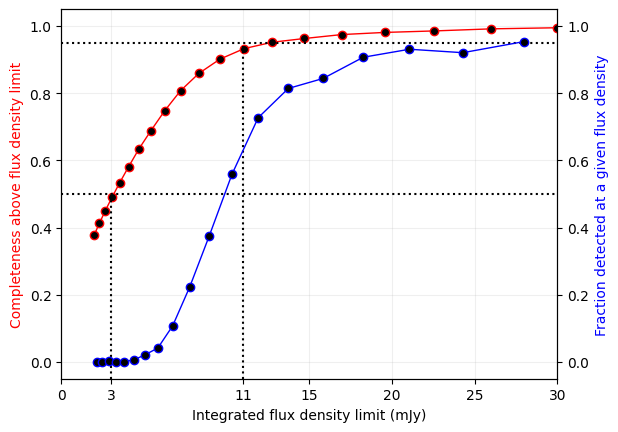

In [ ]:
datafiles = sorted(glob.glob(os.path.expanduser('~/storage/surveytgts/mosaics/healpix-res/*injection.txt')))

if not os.path.exists(os.path.expanduser('~/storage/surveytgts/analysis/concat.fits')):
    # cycle idx ra dec fv rfv efv — keep only sources belonging to their own HEALPix pixel
    tables = []
    for datafile in datafiles:
        pointing_name = os.path.basename(datafile).split('-')[0]
        print('Concatenating %s' % pointing_name)
        tadd = Table.read(datafile, format='ascii')
        tadd['HEALPIX'] = hp.lonlat_to_healpix(tadd['ra'].data*u.deg, tadd['dec'].data*u.deg)
        tadd = tadd[tadd['HEALPIX'] == int(pointing_name[2:])]
        tables.append(tadd)
    t = vstack(tables)

    t['fv'].name = 'f_inj'
    t['rfv'].name = 'f_meas'
    t['efv'].name = 'f_meas_err'    
    
    t['f_inj'] *= 1e3
    t['f_meas'] *= 1e3
    t['f_meas_err'] *= 1e3
    
    t.write(os.path.expanduser('~/storage/surveytgts/analysis/concat.fits'), format='fits')
else:
    t = Table.read(os.path.expanduser('~/storage/surveytgts/analysis/concat.fits'), format='fits')

logmin=np.log10(3)
logmax=np.log10(30)
steps=20

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

# all detected sources are reset to the original value
t['f_meas'][np.where(t['f_meas'] != 0.0)] = t['f_inj'][np.where(t['f_meas'] != 0.0)] 

f_inj_vals = np.histogram(t['f_inj'], bins=10**np.linspace(logmin,logmax,steps))[0].astype(float)
f_meas_vals = np.histogram(t['f_meas'], bins=10**np.linspace(logmin,logmax,steps))[0].astype(float)
ratios = np.divide(f_meas_vals, f_inj_vals, out=np.zeros_like(f_meas_vals), where=f_meas_vals!=0)
print('Ratios:', ratios)

p = []; f = []
for lf in np.linspace(logmin,logmax,steps):
    flux=10**lf

    idxf_det=(t['f_inj']>0) & (t['f_meas']>flux) # idx detected
    idxf_inj=(t['f_inj']>flux) # idx injected

    n1=len(t[idxf_det])
    n2=len(t[idxf_inj])

    f.append(flux)
    p.append(n1/n2)
    print('Fraction %s above %s -- %s of %s -- %s error' % (n1/n2, flux, n1, n2, 1/np.sqrt(n2)) )


ax1.plot(f, p, color='r',markerfacecolor='k',linewidth=1,linestyle='-',marker='o')
print("wendy",f[:-1] + np.diff(f) / 2, ratios)
ax2.plot(f[:-1] + np.diff(f) / 2, ratios, color='b',markerfacecolor='k',linewidth=1,linestyle='-',marker='o')
print('Blue dots:', f[:-1] + np.diff(f) / 2, ratios)

#plt.xlim(1000.0*10**min,1000.0*10**max)
#plt.xlim(1000.0*10**min,1.2)
#plt.ylim(0.2,1.05)
ax1.set_xlabel('Integrated flux density limit (mJy)')
ax1.set_ylabel('Completeness above flux density limit',color='r')
ax2.set_ylabel('Fraction detected at a given flux density',color='b')
# 50%
ax1.axvline(3., ymax=0.5, color='k',ls=':')
ax1.axhline(0.5,color='k',ls=':')
# 90%
#ax1.axvline(9.5, ymax=0.85, color='k',ls=':')
#ax1.axhline(0.9,color='k',ls=':')
# 95%
ax1.axvline(11, ymax=0.9, color='k',ls=':')
ax1.axhline(0.95,color='k',ls=':')
ax1.set_xticks([0,3,11,15,20,25,30])
for i, tick in enumerate(ax1.get_xticklines()):
    if i == 1 or i == 2: tick.set_color('red')
ax1.set_ylim(-0.05,1.05)
ax2.set_ylim(-0.05,1.05)
ax1.set_xlim(0,30)
ax2.set_xlim(0,30)
ax1.grid(alpha=.2)
plt.savefig(os.path.expanduser('~/storage/surveytgts/analysis/completeness.png'), dpi=300, bbox_inches='tight')


FALSE POSITIVES

Total fake sources: 9484
False positive: 1.60%


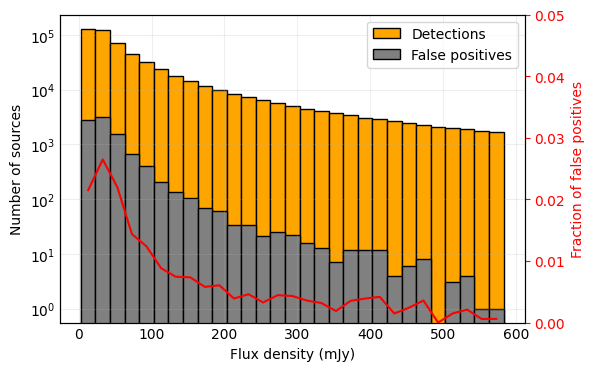

In [4]:
t = Table.read('/homes/fdg/storage/surveytgts/catalogues/LoLSS_DR2-cat.fits', format='fits')
t_fp = Table.read('/homes/fdg/storage/surveytgts/catalogues/catalogues-inv/LoLSS_DR2-inv-cat.fits', format='fits')
print("Total fake sources:", len(t_fp))
print("False positive: %.2f%%" % (100*len(t_fp)/len(t)))

fig = plt.figure(figsize=(6, 4))
fig.subplots_adjust(wspace=0)
ax = fig.add_subplot(111)
ax2 = ax.twinx()
ax.tick_params(direction='in', top=True, right=True)
fig.subplots_adjust(hspace=0)

ax.set_xlabel(r'Flux density (mJy)')
ax.set_ylabel(r'Number of sources')
ax2.set_ylabel(r'Fraction of false positives')
ax.set_yticklabels([])

fd_real = t['Total_flux']
fd_false = t_fp['Total_flux']

bins = np.arange(3, 600, 20)
n_real, bins, patches = ax.hist(fd_real, bins=bins, orientation='vertical', ec='black', histtype='bar', alpha=1, color='orange')
n_false, bins, patches = ax.hist(fd_false, bins=bins, orientation='vertical', ec='black', histtype='bar', alpha=1, color='gray')

bin_w = (max(bins) - min(bins)) / (len(bins) - 1)
ax2.plot(np.arange(min(bins)+bin_w/2, max(bins), bin_w), n_false/n_real, color='red')

ax.tick_params(axis=u'both', which=u'both',length=0)
ax.grid(alpha=.2)
ax.set_yscale('log')
ax2.set_ylim(ymin=0,ymax=.05)
ax2.yaxis.label.set_color('red')
ax2.tick_params(axis='y', colors='red')

#create legend
handles = [Rectangle((0,0),1,1,color=c,ec="k") for c in ['orange','gray']]
labels= ["Detections","False positives"]
ax.legend(handles, labels)

fig.savefig('falsepositive_hist.pdf', bbox_inches='tight', facecolor='w')